In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!cp "/content/drive/MyDrive/archive.zip" "/content/dataset.zip"

In [ ]:
!unzip -q /content/dataset.zip -d /content/skin_data

In [ ]:
import os
import random
import csv
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import Dataset, DataLoader
from PIL import Image
from collections import Counter
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import f1_score, confusion_matrix, classification_report
from tqdm import tqdm
import timm
import seaborn as sns

SEED = 42
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", DEVICE)

NUM_CLASSES = 9
BATCH_SIZE = 8
NUM_EPOCHS = 50
LEARNING_RATE = 1e-4
WEIGHT_DECAY = 1e-4
T_MAX = 20
OVERSAMPLE_FACTOR = 5
PATIENCE = 6

TRAIN_DIR  = "/content/skin_data/Skin cancer ISIC The International Skin Imaging Collaboration/Train"
TEST_DIR   = "/content/skin_data/Skin cancer ISIC The International Skin Imaging Collaboration/Test"
BASE_PATH  = "/content/drive/MyDrive/VĐHĐ_TTNT/Densenet169Only"
RESULT_DIR = os.path.join(BASE_PATH, "results")

checkpoint_path = os.path.join(BASE_PATH, "best_model.pt")
LOG_CSV         = os.path.join(BASE_PATH, "training_log.csv")


RESUME_PATH = os.path.join(BASE_PATH, "last_checkpoint.pt")
START_EPOCH = 1

os.makedirs(BASE_PATH,  exist_ok=True)
os.makedirs(RESULT_DIR, exist_ok=True)


def seed_everything(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True

seed_everything(SEED)


def save_checkpoint(state, filename=RESUME_PATH):
    torch.save(state, filename)

def load_checkpoint(model, optimizer, scheduler):
    if os.path.exists(RESUME_PATH):
        print(f"==> Resuming from checkpoint: {RESUME_PATH}")
        checkpoint = torch.load(RESUME_PATH, map_location=DEVICE)
        model.load_state_dict(checkpoint['state_dict'])
        optimizer.load_state_dict(checkpoint['optimizer'])
        scheduler.load_state_dict(checkpoint['scheduler'])
        start_epoch = checkpoint['epoch'] + 1
        history = checkpoint.get('history', [])
        best_f1 = checkpoint.get('best_f1', 0.0)
        return start_epoch, history, best_f1
    return 1, [], 0.0

# ========================== DATA ==========================
train_dataset_raw = datasets.ImageFolder(TRAIN_DIR)
class RandomAugmentationPerImage:
    def __init__(self):
        self.augmentations = [
            transforms.RandomHorizontalFlip(p=0.5),
            transforms.RandomVerticalFlip(p=0.5),
            transforms.RandomRotation(15),
            transforms.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.1)
        ]
        self.resize = transforms.Resize((224,224))
        self.to_tensor = transforms.ToTensor()
        self.normalize = transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])

    def __call__(self, img):
        img = self.resize(img)
        for aug in self.augmentations:
            if torch.rand(1) < 0.5:
                img = aug(img)
        img = self.to_tensor(img)
        img = self.normalize(img)
        return img

# transform_train = transforms.Compose([
#     transforms.Resize((224,224)),
#     transforms.RandomHorizontalFlip(0.5),
#     transforms.RandomVerticalFlip(0.5),
#     transforms.RandomRotation(40),
#     transforms.ColorJitter(0.2,0.2,0.2),
#     transforms.ToTensor(),
#     transforms.Normalize([0.485,0.456,0.406],
#                          [0.229,0.224,0.225])
# ])
transform_train = RandomAugmentationPerImage()
transform_val = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],
                         [0.229,0.224,0.225])
])
test_dataset = test_dataset = datasets.ImageFolder(TEST_DIR, transform=transform_val)

# ========================== OVERSAMPLING ==========================
targets = [train_dataset_raw.imgs[i][1] for i in range(len(train_dataset_raw.imgs))]
class_counts = Counter(targets)
max_count = max(class_counts.values()) * OVERSAMPLE_FACTOR
weights_per_class = {cls: max_count/count for cls, count in class_counts.items()}
sample_weights = np.array([weights_per_class[t] for t in targets])

indices = np.random.choice(len(targets),
                           size=len(targets)*OVERSAMPLE_FACTOR,
                           replace=True,
                           p=sample_weights/sample_weights.sum())

oversampled_imgs = [train_dataset_raw.imgs[i] for i in indices]
paths, labels = zip(*oversampled_imgs)
paths, labels = np.array(paths), np.array(labels)

train_paths, val_paths, train_labels, val_labels = train_test_split(
    paths, labels, test_size=0.3, stratify=labels, random_state=SEED
)

class CustomDataset(Dataset):
    def __init__(self, paths, labels, transform):
        self.paths = paths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        img = Image.open(self.paths[idx]).convert('RGB')
        img = self.transform(img)
        return img, int(self.labels[idx])

train_loader = DataLoader(CustomDataset(train_paths, train_labels, transform_train),
                          batch_size=BATCH_SIZE, shuffle=True)

val_loader = DataLoader(CustomDataset(val_paths, val_labels, transform_val),
                        batch_size=BATCH_SIZE, shuffle=False)

test_loader = DataLoader(test_dataset,
                         batch_size=BATCH_SIZE, shuffle=False)

# ========================== LOSS ==========================
class_weights = compute_class_weight('balanced',
                                     classes=np.unique(train_labels),
                                     y=train_labels)
class_weights[0] *= 2.5

class_weights = torch.tensor(class_weights, dtype=torch.float32).to(DEVICE)

class FocalLoss(nn.Module):
    def __init__(self, alpha=None, gamma=2):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.ce = nn.CrossEntropyLoss(reduction='none')

    def forward(self, logits, targets):
        ce_loss = self.ce(logits, targets)
        pt = torch.exp(-ce_loss)

        focal_loss = ((1 - pt) ** self.gamma) * ce_loss

        if self.alpha is not None:
            alpha_t = self.alpha[targets]
            focal_loss = alpha_t * focal_loss

        return focal_loss.mean()

# criterion = nn.CrossEntropyLoss(weight=class_weights)

criterion = FocalLoss(alpha=class_weights, gamma=2)

# criterion = nn.CrossEntropyLoss(
#     weight=class_weights,
#     label_smoothing=0.1
# )
# ========================== CBAM ==========================

class ChannelAttention(nn.Module):
    def __init__(self, in_channels, reduction=16):
        super().__init__()
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.max_pool = nn.AdaptiveMaxPool2d(1)
        self.mlp = nn.Sequential(
            nn.Linear(in_channels, in_channels // reduction, bias=False),
            nn.ReLU(),
            nn.Linear(in_channels // reduction, in_channels, bias=False)
        )
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        b, c, _, _ = x.size()
        avg_out = self.mlp(self.avg_pool(x).view(b, c))
        max_out = self.mlp(self.max_pool(x).view(b, c))
        out = self.sigmoid(avg_out + max_out).view(b, c, 1, 1)
        return x * out


class SpatialAttention(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv = nn.Conv2d(2, 1, kernel_size=7, padding=3, bias=False)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        avg_out = torch.mean(x, dim=1, keepdim=True)
        max_out, _ = torch.max(x, dim=1, keepdim=True)
        x_cat = torch.cat([avg_out, max_out], dim=1)
        return self.sigmoid(self.conv(x_cat))


class CBAM(nn.Module):
    def __init__(self, in_channels):
        super().__init__()
        self.ca = ChannelAttention(in_channels)
        self.sa = SpatialAttention()

    def forward(self, x):
        x = self.ca(x)
        x = x * self.sa(x)
        return x


# ========================== MODEL ==========================

import torch
import torch.nn as nn
import timm


# class CrossAttentionFusion(nn.Module):
#     """
#     CNN feat làm Query, Swin feat làm Key/Value.
#     Học cách đặc trưng cục bộ (CNN) chú ý đến đặc trưng toàn cục (Swin).
#     Có residual connection + Feed-Forward Network.
#     """
#     def __init__(self, dim: int = 512, heads: int = 8, dropout: float = 0.1):
#         super().__init__()
#         self.attn  = nn.MultiheadAttention(dim, heads, dropout=dropout,
#                                            batch_first=True)
#         self.norm1 = nn.LayerNorm(dim)
#         self.norm2 = nn.LayerNorm(dim)
#         self.ffn   = nn.Sequential(
#             nn.Linear(dim, dim * 2),
#             nn.GELU(),
#             nn.Dropout(dropout),
#             nn.Linear(dim * 2, dim),
#         )

#     def forward(self, cnn_feat: torch.Tensor, swin_feat: torch.Tensor) -> torch.Tensor:
#         # [B, 512] -> [B, 1, 512]
#         q  = cnn_feat.unsqueeze(1)
#         kv = swin_feat.unsqueeze(1)
#         attended, _ = self.attn(q, kv, kv)
#         # Residual 1: attention + CNN input
#         x = self.norm1(attended.squeeze(1) + cnn_feat)
#         # Residual 2: FFN
#         x = self.norm2(x + self.ffn(x))
#         return x   # [B, 512]

class SwinOnly(nn.Module):
    def __init__(self, num_classes=9):
        super().__init__()

        self.backbone = timm.create_model(
            'densenet169',
            pretrained=True,
            num_classes=0  # bỏ classifier
        )
        in_features = self.backbone.num_features

        self.head = nn.Sequential(
            nn.Linear(in_features, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.backbone(x)   # [B, 1024]
        return self.head(x)

# Khởi tạo model
NUM_CLASSES = 9
model = SwinOnly(num_classes=NUM_CLASSES).to(DEVICE)
optimizer = optim.AdamW(model.parameters(),lr=LEARNING_RATE,weight_decay=WEIGHT_DECAY)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=T_MAX)

start_epoch, history, best_f1 = load_checkpoint(model, optimizer, scheduler)


from sklearn.metrics import f1_score

def evaluate(model, loader):
    model.eval()
    total_loss = 0
    correct = 0
    total = 0

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)

            outputs = model(imgs)
            loss = criterion(outputs, labels)

            total_loss += loss.item()

            preds = outputs.argmax(1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    avg_loss = total_loss / len(loader)
    acc = correct / total

    # 🔥 F1 macro (quan trọng cho dataset lệch class)
    f1 = f1_score(all_labels, all_preds, average='macro')

    return avg_loss, acc, f1, all_preds, all_labels
# ========================== TRAIN ==========================

# best_f1 = 0
# history = []

if start_epoch == 1:
    with open(LOG_CSV, 'w', newline='') as f:
        writer = csv.writer(f)
        writer.writerow(["epoch","loss","val_loss","acc","val_acc","val_f1"])

for epoch in range(start_epoch, NUM_EPOCHS + 1):

    print(f"\nEpoch {epoch}/{NUM_EPOCHS}")

    # ===== TRAIN =====
    model.train()
    train_loss = 0
    correct = 0
    total = 0

    for imgs, labels in tqdm(train_loader, desc="TRAIN"):
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)

        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        train_loss += loss.item()

        preds = outputs.argmax(1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    train_loss /= len(train_loader)
    train_acc = correct / total

    # ===== VALIDATION =====
    val_loss, val_acc, val_f1, val_preds, val_labels = evaluate(model, val_loader)

    scheduler.step()

    # 🔥 PRINT FULL METRICS
    print(f"Loss: {train_loss:.4f} | Acc: {train_acc:.4f}")
    print(f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f} | Val F1: {val_f1:.4f}")

    history.append([epoch, train_loss, val_loss, train_acc, val_acc, val_f1])

    # save log
    with open(LOG_CSV, 'a', newline='') as f:
        writer = csv.writer(f)
        writer.writerow([epoch, train_loss, val_loss, train_acc, val_acc, val_f1])

    # 🔥 SAVE BEST THEO F1 (quan trọng hơn acc)
    if val_f1 > best_f1:
        best_f1 = val_f1
        torch.save(model.state_dict(), checkpoint_path)
        print("✓ Saved best model (by F1)")

    # checkpoint
    save_checkpoint({
        'epoch': epoch,
        'state_dict': model.state_dict(),
        'optimizer': optimizer.state_dict(),
        'scheduler': scheduler.state_dict(),
        'history': history,
        'best_f1': best_f1
    })

# ========================== TEST ==========================
print("\nTesting best model...")
model.load_state_dict(torch.load(checkpoint_path, map_location=DEVICE))
model.eval()

preds_all, labels_all = [], []

with torch.no_grad():
    for imgs, lbl in tqdm(test_loader, desc="TEST"):
        imgs = imgs.to(DEVICE)
        out = model(imgs)
        preds = out.argmax(1)
        preds_all.extend(preds.cpu().numpy())
        labels_all.extend(lbl.numpy())

print(classification_report(labels_all, preds_all))

cm = confusion_matrix(labels_all, preds_all)
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.savefig(os.path.join(RESULT_DIR,"confusion_matrix.png"))
plt.show()

Device: cuda



Epoch 1/50


TRAIN: 100%|██████████| 980/980 [03:54<00:00,  4.18it/s]


Loss: 0.8158 | Acc: 0.5815
Val Loss: 0.2769 | Val Acc: 0.8053 | Val F1: 0.7975
✓ Saved best model (by F1)

Epoch 2/50


TRAIN: 100%|██████████| 980/980 [03:54<00:00,  4.19it/s]


...

Loss: 0.0409 | Acc: 0.9555
Val Loss: 0.0645 | Val Acc: 0.9464 | Val F1: 0.9460

Epoch 22/50


TRAIN: 100%|██████████| 980/980 [03:57<00:00,  4.13it/s]


Loss: 0.0413 | Acc: 0.9541
Val Loss: 0.0631 | Val Acc: 0.9470 | Val F1: 0.9466

Epoch 23/50


TRAIN:  38%|███▊      | 372/980 [01:33<02:33,  3.96it/s]


KeyboardInterrupt: 


Testing best model...


TEST: 100%|██████████| 15/15 [00:08<00:00,  1.79it/s]
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(resu

              precision    recall  f1-score   support

           0       0.50      0.06      0.11        16
           1       0.72      0.81      0.76        16
           2       1.00      0.69      0.81        16
           3       0.22      0.12      0.16        16
           4       0.35      1.00      0.52        16
           5       0.86      0.75      0.80        16
           6       0.00      0.00      0.00         3
           7       0.79      0.69      0.73        16
           8       0.75      1.00      0.86         3

    accuracy                           0.58       118
   macro avg       0.58      0.57      0.53       118
weighted avg       0.62      0.58      0.55       118



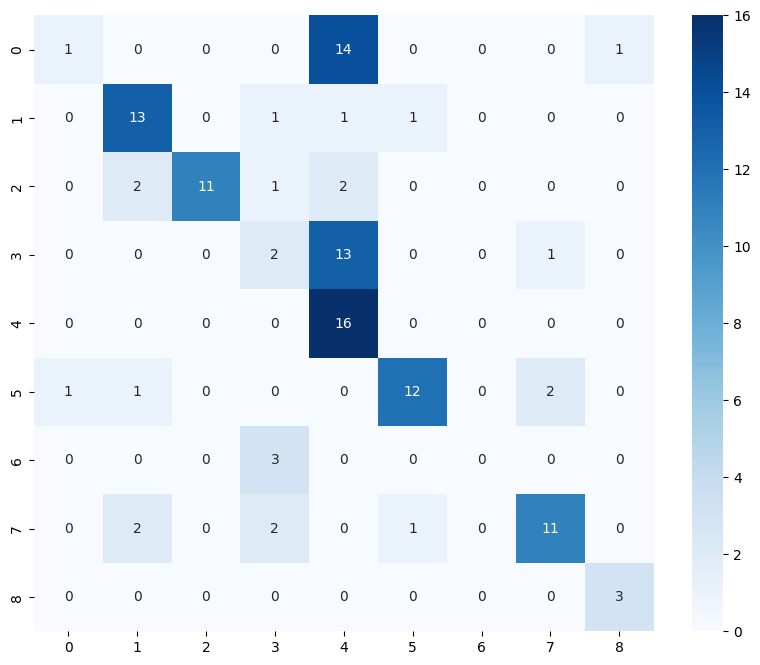

In [ ]:
print("\nTesting best model...")
model.load_state_dict(torch.load(checkpoint_path, map_location=DEVICE))
model.eval()

preds_all, labels_all = [], []

with torch.no_grad():
    for imgs, lbl in tqdm(test_loader, desc="TEST"):
        imgs = imgs.to(DEVICE)
        out = model(imgs)
        preds = out.argmax(1)
        preds_all.extend(preds.cpu().numpy())
        labels_all.extend(lbl.numpy())

print(classification_report(labels_all, preds_all))

cm = confusion_matrix(labels_all, preds_all)
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.savefig(os.path.join(RESULT_DIR,"confusion_matrix.png"))
plt.show()